In [1]:
try:
    import ydf
except:
    %pip install -U ydf
    import ydf

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

import warnings

2026-03-14 21:19:07.054137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773523147.384277      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773523147.480514      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773523148.218208      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773523148.218278      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773523148.218281      17 computation_placer.cc:177] computation placer alr

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e3/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']] 
BASE   = NUMS + CATS

train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16
Total base features: 19


In [6]:
display(train.head())
train.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [7]:
train[NUMS].describe()

,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000


In [8]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


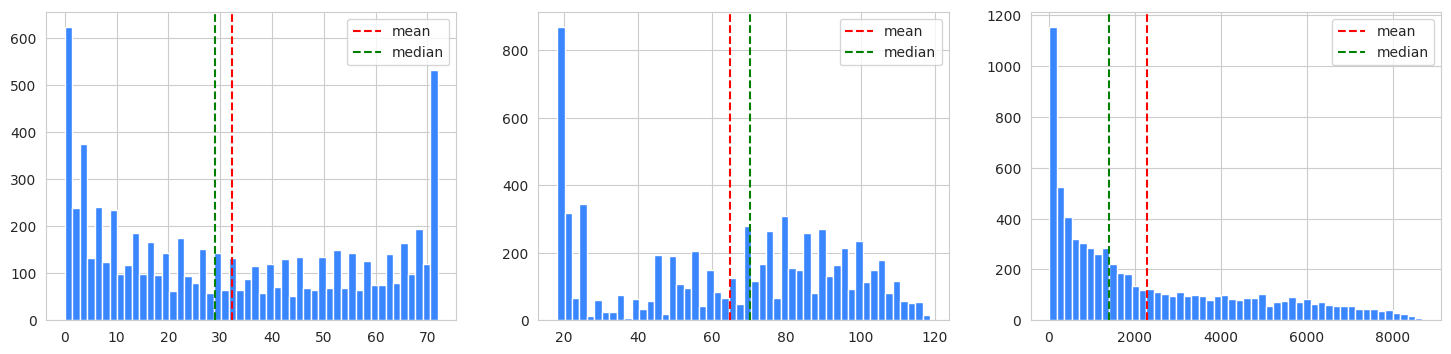

In [9]:
plt.figure(figsize=(18, 4))
for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.legend()
    
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


## FEATURE ENGINEERING

In [11]:
# ## -- Append predicted columns as extra features --
# ## -- os.walk: Deep search with subfolders --
# def dataloader(filepath):    
#     train_df = pd.DataFrame()
#     test_df = pd.DataFrame()
    
#     # print("Loading .npy: ", end="")
#     # for (root, dirs, files) in os.walk(filepath):
#     #     for i, file in enumerate(sorted(files), 1):
#     #         if i%5 == 0: print(f"{i}%.. ", end="")
#     #         if file.endswith(".npy") and "train" in file:
#     #             train_path = np.load(os.path.join(root, file))
#     #             train = pd.concat([train, pd.Series(train_path, name=file[6:-4])], axis=1)
#     #         elif file.endswith(".npy") and "test" in file:
#     #             test_path = np.load(os.path.join(root, file))
#     #             test = pd.concat([test, pd.Series(test_path, name=file[5:-4])], axis=1)
#     # print()
#     print("Loading .parquet files: ", end="")
#     for (root, dirs, files) in os.walk(filepath):
#         for i, file in enumerate(sorted(files), 1):
#             if i%5 == 0: print(f"{i}%.. ", end="")
#             if file.endswith(".parquet") and "train" in file:
#                 train_path = os.path.join(root, file)
#                 train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
#             elif file.endswith(".parquet") and "test" in file:
#                 test_path = os.path.join(root, file)
#                 test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
#     print()
#     print(f"Total train models: {len(train_df.columns)} || Shape: {train_df.shape}")
#     print(f"Total test models : {len(test_df.columns)} || Shape: {test_df.shape}")
#     print()

#     return train_df, test_df

In [12]:
# PATHS = [
#     # '/kaggle/input/ps6e1-per-feature-ag',
#     '/kaggle/input/ps6e1-autogluon-trainorig',
#     # '/kaggle/input/ps6e1-lr-gbdt-nn-trainorig',
# ]

# ## -- Load dataframes --
# train_dfs = []
# test_dfs  = []

# ## -- Load train/test datasets --
# for p in PATHS:
#     tr, ts = dataloader(p)
#     train_dfs.append(tr)
#     test_dfs.append(ts)

# ## -- Concat datasets --
# ext_train = pd.concat(train_dfs, axis=1)
# ext_test  = pd.concat(test_dfs, axis=1)

# print('External data loaded', ext_train.shape, ext_test.shape)

# ## -- Drop weighted autogluon models --
# for c in ext_train.columns:
#     if 'L2' in c or 'L3' in c: # 
#         ext_train.drop([c], axis=1, inplace=True)
#         ext_test.drop([c], axis=1, inplace=True)
#     elif c == TARGET:
#         ext_train.drop([c], axis=1, inplace=True)
    
# ## -- Check for missing values --
# print('Check missingness:', ext_train.isna().sum().sum(), ext_test.isna().sum().sum())

# display(ext_train.head(3))
# display(ext_test.head(3))

In [13]:
# %%time

# plt.figure(figsize=(18, 5))
# ext_train.boxplot()
# # sns.boxplot(ext_train)
# plt.tick_params(axis='x', rotation=90)

In [14]:
# ## -- Merge datasets --
# top_cols = ext_train.columns.tolist()

# train = pd.concat([train, ext_train], axis=1)
# test = pd.concat([test, ext_test], axis=1)

# train.head(3)

In [15]:
# ## -- EXTRACTIONS & BINNING --
# ROUNDS = []
# DIGITS = []
# E_BINS = []
# Q_BINS = []

In [16]:
# for col in ['TotalCharges']:
#     # print(f"\nEXTRACTING ROUNDS... ", end='')
#     # for r in [-3, -2, -1, 0, 1]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() <= 2:
#     #         train = train.drop([r_n], axis=1)
#     #         test  = test.drop([r_n], axis=1)
#     #         orig  = orig.drop([r_n], axis=1)
#     #     elif train[r_n].nunique() == train[col].nunique():
#     #         train = train.drop([r_n], axis=1)
#     #         test  = test.drop([r_n], axis=1)
#     #         orig  = orig.drop([r_n], axis=1)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nEXTRACTING DIGITS... ", end='')
#     for d in [-3, -2, -1, 0, 1, 2]:
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         ## -- Drop constant features --
#         if train[d_n].nunique() < 2:
#             train = train.drop([d_n], axis=1)
#             test  = test.drop([d_n], axis=1)
#             orig  = orig.drop([d_n], axis=1)
#         else:
#             DIGITS.append(d_n)

#     print(f"\nCREATING E_BINS... ", end='')
#     for b in [400]: # 100, 500, 1000
#         b_n = f'{col}_bin_{b}'
#         print(b_n+', ', end='')
#         train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#         test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         E_BINS.append(b_n)

#     print(f"\nQUANTILE BINNING... ", end='')
#     for q in [1000]: # 100, 500, 1000
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)
        
# print()
# print('='*50)
# print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')
# print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}")
# print(f"✅ TOTAL EQUAL E_BINS: {len(E_BINS)}")
# print(f"✅ TOTAL QUANTILE E_BINS: {len(Q_BINS)}")

In [17]:
# for col in ['MonthlyCharges']:
#     # print(f"\nROUNDING FEATURES... ", end='')
#     # for r in [-2, -1, 0]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() <= 2:
#     #         train = train.drop([r_n], axis=1)
#     #         test  = test.drop([r_n], axis=1)
#     #         orig  = orig.drop([r_n], axis=1)
#     #     elif train[r_n].nunique() == train[col].nunique():
#     #         train = train.drop([r_n], axis=1)
#     #         test  = test.drop([r_n], axis=1)
#     #         orig  = orig.drop([r_n], axis=1)
#     #     else:
#     #         ROUNDS.append(r_n)
    
#     print(f"\nEXTRACTING DIGITS... ", end='')
#     for d in [-2, -1, 0, 1, 2]:
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < 2:
#             train = train.drop([d_n], axis=1)
#             test  = test.drop([d_n], axis=1)
#             orig  = orig.drop([d_n], axis=1)
#         else:
#             DIGITS.append(d_n)
            
#     print(f"\nEQUAL BINNING... ", end='')
#     for b in [100]: # 50, 100, 400
#         b_n = f'{col}_bin_{b}'
#         print(b_n+', ', end='')
#         # Fit on train data and transform both train and test
#         train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#         test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         E_BINS.append(b_n)
        
#     print(f"\nQUANTILE BINNING... ", end='')
#     for q in [500]: # 50, 100, 400
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f"✅ TOTAL DIGITS: {len(DIGITS)}")
# print(f'✅ TOTAL ROUNDs: {len(ROUNDS)}')
# print(f"✅ TOTAL EQUAL BINS: {len(E_BINS)}")
# print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS)}")

In [18]:
# for col in ['tenure']:
#     # print(f"\nEXTRACTING ROUNDS... ", end='')
#     # for r in [-1]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() <= 2:
#     #         train = train.drop([r_n], axis=1)
#     #         test  = test.drop([r_n], axis=1)
#     #         orig  = orig.drop([r_n], axis=1)
#     #     elif train[r_n].nunique() == train[col].nunique():
#     #         train = train.drop([r_n], axis=1)
#     #         test  = test.drop([r_n], axis=1)
#     #         orig  = orig.drop([r_n], axis=1)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nEXTRACTING DIGITS... ", end='')
#     for d in [-1, 0]:
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         ## -- Drop constant features --
#         if train[d_n].nunique() < 2:
#             train = train.drop([d_n], axis=1)
#             test  = test.drop([d_n], axis=1)
#             orig  = orig.drop([d_n], axis=1)
#         else:
#             DIGITS.append(d_n)

#     print(f"\nEQUAL BINNING... ", end='')
#     for b in [10, 50]: # 10, 50, 100
#         b_n = f'{col}_bin_{b}'
#         print(b_n+', ', end='')
#         # Fit on train data and transform both train and test
#         train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#         test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         E_BINS.append(b_n)

#     print(f"\nQUANTILE BINNING... ", end='')
#     for q in [10, 50]: # 10, 50, 100
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
# print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
# print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
# print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")

In [19]:
# ALL_ROUND_BINS = ROUNDS + E_BINS + Q_BINS

# train[ALL_ROUND_BINS].nunique().sort_values()

In [20]:
# LOW_100_UNIQUE = []

# for col in ALL_ROUND_BINS:
#     if train[col].nunique() < 100:
#         LOW_100_UNIQUE.append(col)

# print(f"Cats with ~100 unique: {len(LOW_100_UNIQUE)}")
# print()
# TOP_100_UNIQUE = [c for c in ALL_ROUND_BINS if c not in LOW_100_UNIQUE]
# print(f"Cats with +100 unique: {len(TOP_100_UNIQUE)}")

In [21]:
# ## -- Arithmetic interaction --
# for df in [train, test, orig]:
#     df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
#     df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
#     df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

# arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
#               '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

# train[arithmetic].head()

In [22]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [23]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCREATING FREQUENCIES... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_FREQ'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)
    
# print()
# print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")

In [24]:
# INTER = []
# TOP_CATS = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

# for c1, c2 in tqdm(list(itertools.combinations(TOP_CATS+DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_CATS[:4], 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='One-To-Many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(new_col)

# print(f"TOTAL INTERACTION FEATURES: {len(INTER)}")

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [26]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [27]:
# train, test, _, NEW_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [28]:
# ## -- DUPLICATE 'tunure' AS CATEGORICAL --
# for df in [train, test, orig]:
#     df['cat_tenure'] = df['tenure'].values

In [29]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3) 

Total Features: 19


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,0


# ML TRAINING

In [30]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats, seed):
    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")
    start = time()
    
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} - ", end='')

        # Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # cme_cats = NUMS 
        # cme_cols = []
        # print(f"CategoryMeanEncoding: {len(cme_cats)} | ", end='')
        # for c in cme_cats:
        #     n = f"CME_{c}"
        #     CME = CategoryMeanTransformer(cat_cols=[c])
        #     X_train[n] = CME.fit_transform(X_train[[c]], y_train).fillna(-1).astype('int32')
        #     X_val[n]   = CME.transform(X_val[[c]]).fillna(-1).astype('int32')
        #     X_test[n]  = CME.transform(X_test[[c]]).fillna(-1).astype('int32')
        #     cme_cols.append(n)

        # ## -- TE Opt1. -> Using CUSTOM --
        # TE = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        # X_train = TE.fit_transform(X_train, pd.Series(y_train))
        # X_val   = TE.transform(X_val)
        # X_test  = TE.transform(X_test)

        # ## -- TE Opt1. -> Using CUSTOM --
        # TE = TargetEncoder(ALL_ROUND_BINS, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = TE.fit_transform(X_train, pd.Series(y_train))
        # X_val   = TE.transform(X_val)
        # X_test  = TE.transform(X_test)

        # for c in cats:
        #     cm_enc = CategoryMeanTransformer(cat_cols=[c])
        #     X_train[c] = cm_enc.fit_transform(X_train[[c]], y_train)
        #     X_val[c]   = cm_enc.transform(X_val[[c]])
        #     X_test[c]  = cm_enc.transform(X_test[[c]])

        combined = pd.concat([X_train, X_val, X_test])
        for c in cats:
            combined[c] = combined[c].astype(str).astype('category')
        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        print(f"Train shape: {X_train.shape} -")

        ## -- To enable ydf read numerical as categories --
        flat_features = []
        for f in cats: 
            flat_features.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

        ## -- Build model --
        model = ydf.GradientBoostedTreesLearner(
            task=ydf.Task.CLASSIFICATION,
            label=TARGET,
            **params,
            random_seed=seed,
            # features=flat_features,   # 1. Semantic for categories goes here
            # include_all_columns=True, # 2. Include all features for training
        ).train(ds=pd.concat([X_train, y_train], axis=1), valid=pd.concat([X_val, y_val], axis=1), verbose=2)

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model.predict(X_val)
        test_preds += model.predict(X_test)

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f'{YELLOW} • FOLD {idx + 1} AUC: {fold_auc:.5f}{RESET}')

        ## -- Clean up memory --
        del X_train, y_train, y_val, X_test
        gc.collect() 

    # Average the test predictions
    test_preds /= kf.n_splits
    
    # Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • FOLD {i+1} AUC: {score:.5f}")
    
    ## -- Final out-of-fold AUC
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins')
    
    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
        'val_data': X_val, 
    }

print('⚙️⚙️ Training Function Ready ⚙️⚙️')

⚙️⚙️ Training Function Ready ⚙️⚙️


In [31]:
version_name = 'ydfV1_'

all_model_predictions = {}

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [32]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
258396,Male,0,Yes,Yes,40,No,No phone service,DSL,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,48.95,2066.00,1
227119,Female,0,Yes,No,15,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.70,324.15,0
341396,Female,1,No,No,49,Yes,No,DSL,No,Yes,Yes,Yes,Yes,No,Month-to-month,Yes,Mailed check,71.10,2570.20,0


In [33]:
# %%time

# ## -- Search HPO space for 'LOCAL' & 'BEST_FIRST_GLOBAL' --
# tuner = ydf.RandomSearchTuner(num_trials=10, automatic_search_space=False)
# # tuner.choice('num_trees', [5000, 2000])
# # tuner.choice('shrinkage', [0.02, 0.05]) 
# # tuner.choice('subsample', [0.9, 1.0])
# tuner.choice('categorical_algorithm', ['CART', 'RANDOM']) #'CART', 'ONE_HOT', 'RANDOM'
# # tuner.choice('l2_regularization', [0.05, 0.1, 0.2, 0.5, 1.0])

# ## -- 'LOCAL' acts like 'depthwise': uses 'max_depth' --
# local_subspace = tuner.choice('growing_strategy', ['LOCAL'])
# local_subspace.choice('max_depth', [4])

# # # ## -- 'BEST_FIRST_GLOBAL' acts like 'lossguide': uses 'max_num_nodes' --
# # global_subspace = tuner.choice('growing_strategy', ['BEST_FIRST_GLOBAL'], merge=True)
# # global_subspace.choice('max_num_nodes', [32, 64])

# ## -- Enable ydf process numeric features as categories --
# num_as_cat = []

# for f in CATS+DIGITS:
#     num_as_cat.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

# ydf_HPO_model = ydf.GradientBoostedTreesLearner(
#     task=ydf.Task.CLASSIFICATION,
#     label=TARGET, 
#     max_depth=4,
#     num_trees=10_000,
#     shrinkage=0.05,
#     features=num_as_cat,
#     include_all_columns=True,
#     # l2_regularization=0.15,
#     # categorical_algorithm='RANDOM',
#     # early_stopping_initial_iteration=10,
#     early_stopping_num_trees_look_ahead=100,
#     random_seed=SEED, 
#     tuner=tuner,
#     num_threads=os.cpu_count(), 
# ).train(x_train)

# ydf_HPO_model.describe()

In [34]:
# ydf_HPO_model.evaluate(x_test)

In [35]:
# ydf_HPO_model.plot_tree()

In [36]:
# optimizer_logs = ydf_HPO_model.hyperparameter_optimizer_logs()
# print("Total number of trials:", len(optimizer_logs.trials))

# # # Accessing the first trial
# # first_trial = optimizer_logs.trials[0]
# # print(f"\nFirst Trial Score (absolute): {abs(first_trial.score):.4f}")
# # print("First Trial Parameters:")
# # for param, value in first_trial.params.items():
# #     print(f"  {param}: {value}")

# # Iterate through all trials to find the best one (smallest absolute score)
# best_abs_score = float('inf') # Initialize to a very large number for minimization
# best_params = None

# for i, trial in enumerate(optimizer_logs.trials):
#     current_abs_score = abs(trial.score)
#     print(f"\nTrial {i+1}: Score (abs) = {current_abs_score:.5f}")
#     # print(f"  Parameters: {trial.params}") # Uncomment to see all parameters for each trial

#     if current_abs_score < best_abs_score:
#         best_abs_score = current_abs_score
#         best_params = trial.params

# print(f"\nBest Trial Score (abs): {best_abs_score:.5f}") 
# print("Best Trial Parameters:")
# if best_params:
#     for param, value in best_params.items():
#         print(f"  {param}: {value}")

# param_df = pd.Series(data=best_params, dtype='str', name='ydf_HPO_params')
# param_df.to_csv('ydf_best_params.csv', index=False)

# param_df

In [37]:
USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

if all_model_predictions:
    all_model_predictions.clear()

PARAMS = {
    'growing_strategy': 'BEST_FIRST_GLOBAL',
    'num_trees': 10_000,
    # 'max_num_nodes': 2,
    'shrinkage': 0.05,
    # 'categorical_algorithm': 'CART',
    'early_stopping_num_trees_look_ahead': 300,
    # 'l2_regularization': 1.0,
    # 'subsample': 0.8,
}

for algo in ['RANDOM', 'CART']: # , SEED_2, SEED_3, SEED_4, SEED_5
    PARAMS['categorical_algorithm'] = algo
    n = version_name + 'global_' + str(algo)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=CATS, #+DIGITS+['cat_tenure'],
        seed=SEED,
    ) 


==================== Starting Cross-Validation for ydfV1_global_RANDOM ====================

***** FOLD 1/10 - Train shape: (534774, 19) -


[Warning] Column 'SeniorCitizen' is detected as CATEGORICAL but its values look like numbers (e.g., b'1, 0'). Should the column not be NUMERICAL instead? If so, feed numerical values instead of strings or objects.


Train model on 534774 training examples and 59420 validation examples
Model trained in 0:06:00.532862
 • FOLD 1 AUC: 0.91782

***** FOLD 2/10 - Train shape: (534774, 19) -
Train model on 534774 training examples and 59420 validation examples
Model trained in 0:05:43.723734
 • FOLD 2 AUC: 0.91694

***** FOLD 3/10 - Train shape: (534774, 19) -
Train model on 534774 training examples and 59420 validation examples
Model trained in 0:05:20.665894
 • FOLD 3 AUC: 0.91917

***** FOLD 4/10 - Train shape: (534774, 19) -
Train model on 534774 training examples and 59420 validation examples
Model trained in 0:05:01.068436
 • FOLD 4 AUC: 0.91707

***** FOLD 5/10 - Train shape: (534775, 19) -
Train model on 534775 training examples and 59419 validation examples
Model trained in 0:05:21.862145
 • FOLD 5 AUC: 0.91708

***** FOLD 6/10 - Train shape: (534775, 19) -
Train model on 534775 training examples and 59419 validation examples
Model trained in 0:06:05.572733
 • FOLD 6 AUC: 0.91817

***** FOLD 7/1

In [38]:
# ==================================================
# Cross-Validation Results for ydfV1_global_RANDOM
# ==================================================
#  • FOLD 1 AUC: 0.91550
#  • FOLD 2 AUC: 0.91264
#  • FOLD 3 AUC: 0.91614
#  • FOLD 4 AUC: 0.91422
#  • FOLD 5 AUC: 0.91561
# -------------------------------------------------|
# Overall AUC: 0.9148
# Average AUC: 0.914822 ± 0.001260
# -------------------------------------------------|
# 3.76 mins

In [39]:
# USE_FULL_TRAIN = False
# train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

# if all_model_predictions:
#     all_model_predictions.clear()

PARAMS = {
    'growing_strategy': 'LOCAL',
    'num_trees': 10_000,
    'max_depth': 3,
    'shrinkage': 0.05,
    'categorical_algorithm': 'RANDOM',
    'early_stopping_num_trees_look_ahead': 300,
    # 'l2_regularization': 1.0,
    # 'subsample': 0.8,
}

print(f"Using data: {train_data.shape}\n")

for algo in ['CART', 'RANDOM']: # , SEED_2, SEED_3, SEED_4, SEED_5
    PARAMS['categorical_algorithm'] = algo
    n = version_name + 'local_' + str(algo)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=CATS, #+DIGITS+['cat_tenure'],
        seed=SEED,
    ) 

Using data: (594194, 20)


==================== Starting Cross-Validation for ydfV1_local_CART ====================

***** FOLD 1/10 - Train shape: (534774, 19) -
Train model on 534774 training examples and 59420 validation examples
Model trained in 0:11:27.648867
 • FOLD 1 AUC: 0.91802

***** FOLD 2/10 - Train shape: (534774, 19) -
Train model on 534774 training examples and 59420 validation examples
Model trained in 0:11:33.276292
 • FOLD 2 AUC: 0.91732

***** FOLD 3/10 - Train shape: (534774, 19) -
Train model on 534774 training examples and 59420 validation examples
Model trained in 0:11:32.190184
 • FOLD 3 AUC: 0.91941

***** FOLD 4/10 - Train shape: (534774, 19) -
Train model on 534774 training examples and 59420 validation examples
Model trained in 0:11:33.597464
 • FOLD 4 AUC: 0.91736

***** FOLD 5/10 - Train shape: (534775, 19) -
Train model on 534775 training examples and 59419 validation examples
Model trained in 0:11:38.161069
 • FOLD 5 AUC: 0.91727

***** FOLD 6/10 - Train

In [40]:
# ==================================================
# Cross-Validation Results for YDFv1_local_42
# ==================================================
# Fold 1 AUC: 0.95597
# Fold 2 AUC: 0.95470
# Fold 3 AUC: 0.95564
# Fold 4 AUC: 0.95525
# Fold 5 AUC: 0.95607
# -------------------------------------------------|
# Overall AUC: 0.955526
# Average AUC: 0.955526 ± 0.000502
# -------------------------------------------------|
# 11.90 mins

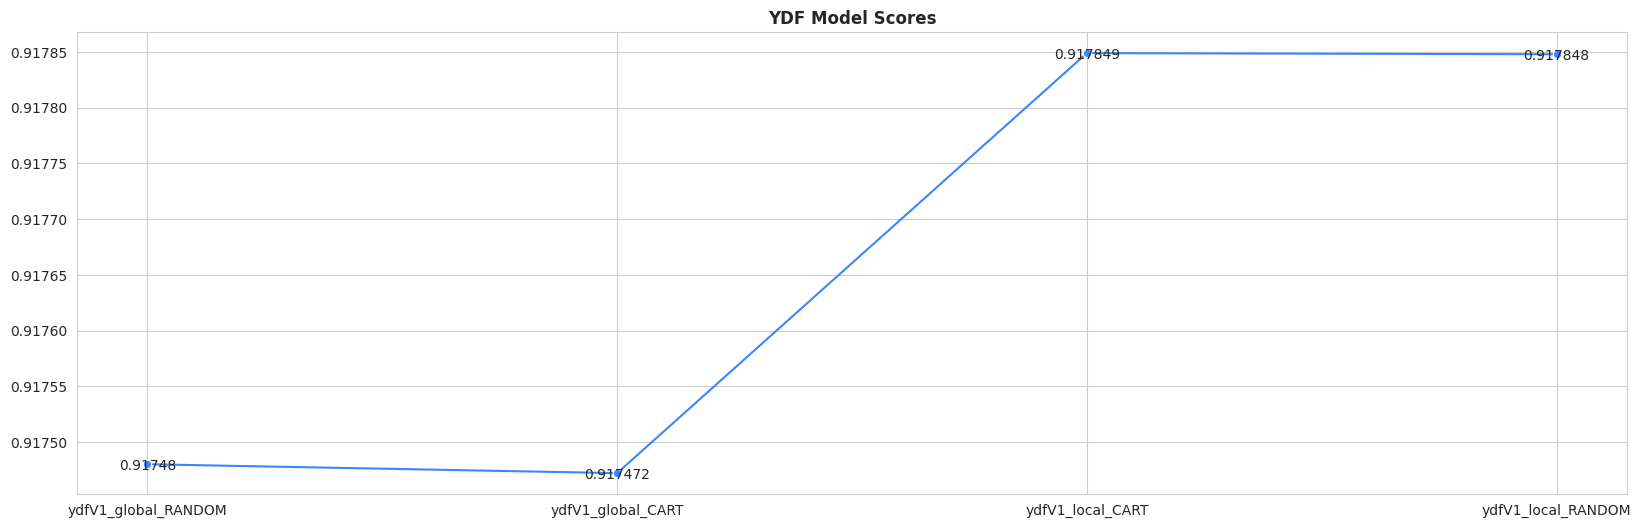

In [41]:
## -- Get models scores --
all_model_scores = {}

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

plt.figure(figsize=(20, 6))
sns.lineplot(all_model_scores, marker='o')
# pd.Series(all_model_scores).plot(marker='o')
plt.title('YDF Model Scores', fontweight='semibold')
# plt.tick_params('x', rotation=45)

for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+1e-7, score, ha='center', va='center_baseline')
    
plt.show()

In [42]:
## -- Get oof predictions --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}_models.parquet", index=False)
all_model_oof.head()

,ydfV1_global_RANDOM_91748,ydfV1_global_CART_917472,ydfV1_local_CART_917849,ydfV1_local_RANDOM_917848
0,0.010535,0.011461,0.011103,0.011103
1,0.002274,0.002336,0.001490,0.001449
2,0.237878,0.240150,0.263256,0.260755
3,0.669774,0.641285,0.830391,0.828650
4,0.765753,0.770062,0.754853,0.754853


In [43]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}_models.parquet", index=False)
all_model_test.head()

,ydfV1_global_RANDOM_91748,ydfV1_global_CART_917472,ydfV1_local_CART_917849,ydfV1_local_RANDOM_917848
0,0.072972,0.072320,0.069907,0.070649
1,0.001935,0.001949,0.001675,0.001681
2,0.121864,0.127383,0.109979,0.110319
3,0.003430,0.003512,0.002675,0.002682
4,0.511398,0.512360,0.513921,0.512375


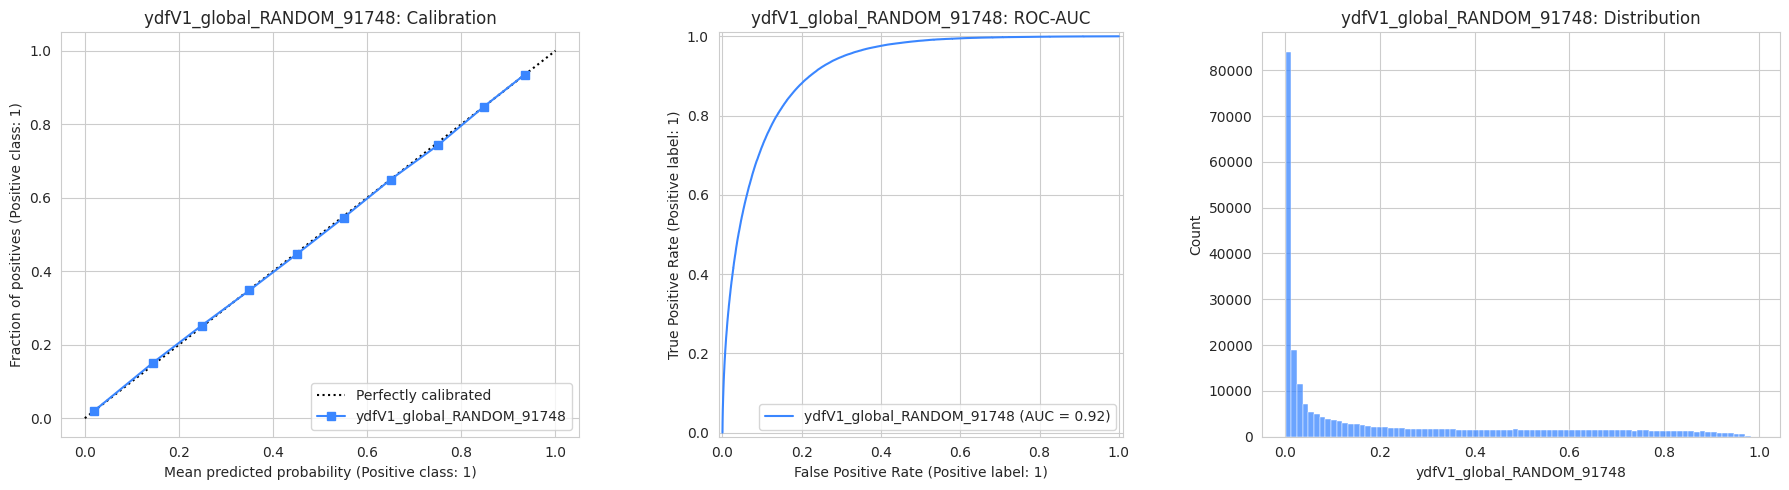

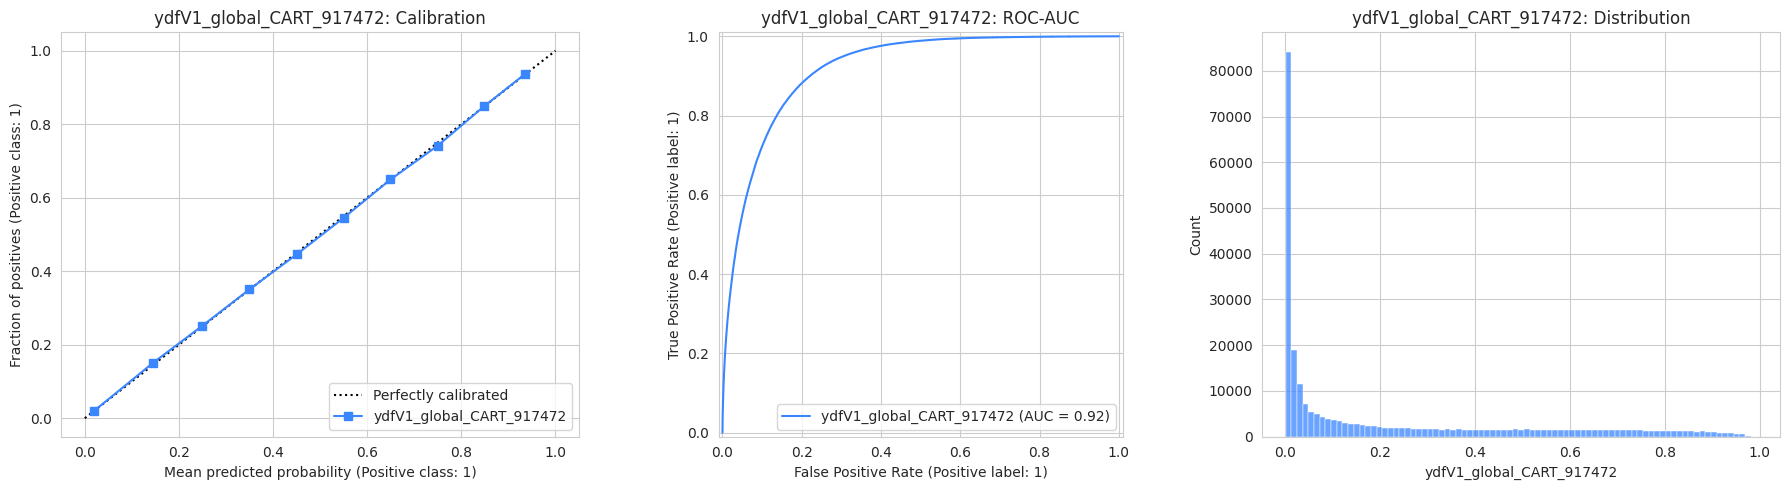

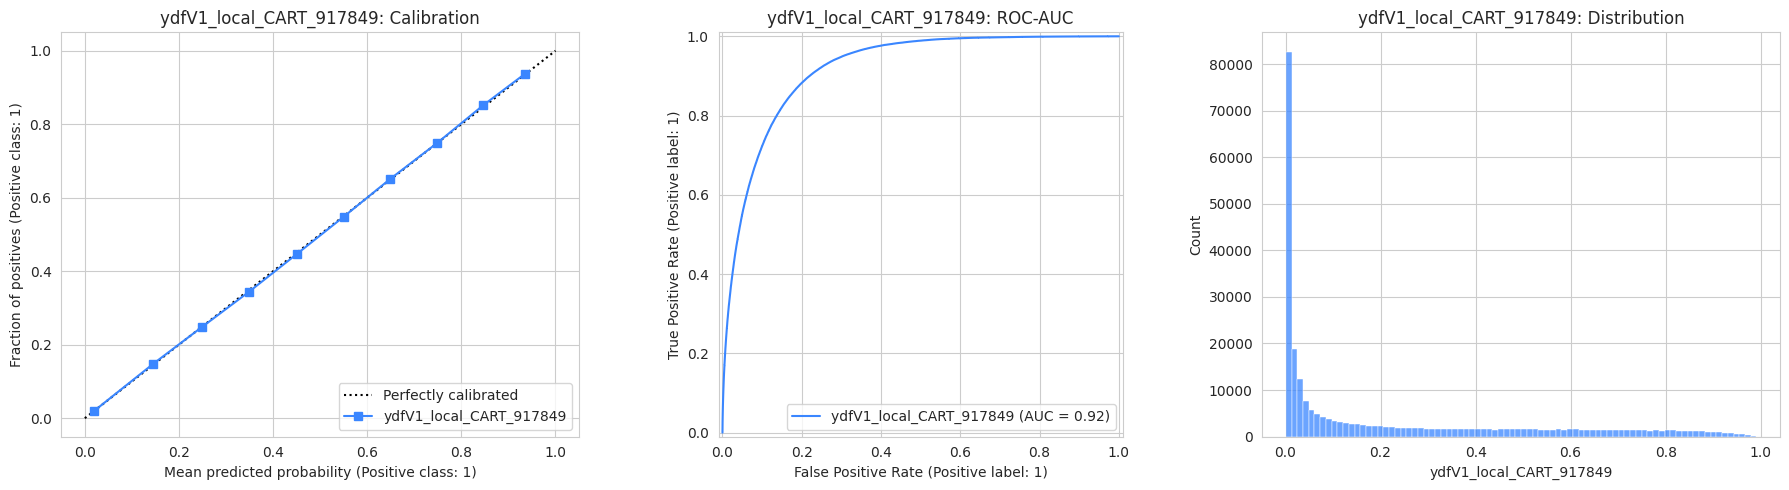

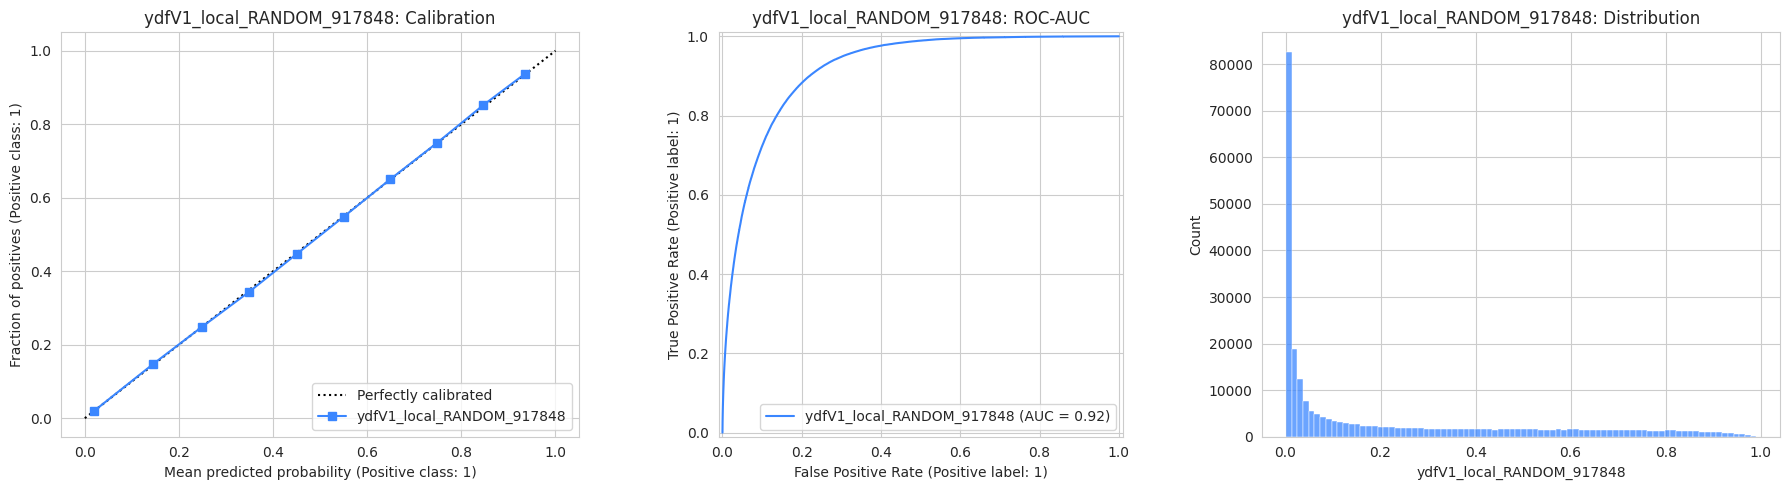

In [44]:
# ## -- PLOT PREDICTIONS --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5)) 

    CalibrationDisplay.from_predictions(train_data[TARGET], all_model_oof[n], n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibration")

    RocCurveDisplay.from_predictions(train_data[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")

    plt.tight_layout()
    plt.show()
    print()

In [45]:
for k, v in all_model_predictions.items():
    print(k)

ydfV1_global_RANDOM
ydfV1_global_CART
ydfV1_local_CART
ydfV1_local_RANDOM


In [46]:
for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'model':
            print(f"\n|{'='*52}|")
            print(f"{'='*16} {k} Model Inpection {'='*16}")
            print(f"|{'='*52}|")
            display(y.describe())
            display(y.plot_tree())
        # break


|====================================================|
================ ydfV1_global_RANDOM Model Inpection ================
|====================================================|



|====================================================|
================ ydfV1_global_CART Model Inpection ================
|====================================================|



|====================================================|
================ ydfV1_local_CART Model Inpection ================
|====================================================|



|====================================================|
================ ydfV1_local_RANDOM Model Inpection ================
|====================================================|
